# Lecture 9b — Building a product universe from holdings

**AI-integrated Sustainable Finance (25881) · Lab 9b**

---

In Lab 9a you audited products you could not see inside. Here you build them.

Take one universe of listed companies. Apply five screening rules, each a
faithful version of a strategy you met in the lecture — exclusion,
best-in-class, norms-based, integration, leaders-only. Every one of them could
honestly be sold as sustainable. Then measure how far apart they are, what each
one actually holds, and whether a claim made about one of them survives contact
with its portfolio.

The lesson is the mirror image of Lab 9a. There, products with the same label
held different things. Here, **reasonable rules applied to the same universe
produce portfolios that barely resemble one another** — which is why a label,
on its own, cannot tell you which rule you bought.

### How to read this notebook

* **Narrative track** — plain prose and code.
* **Maths track** — the collapsible grey boxes.

Exercises are tiered **Core** and **Stretch**.

### The data, and one caveat to keep in view

S&P 500 constituents with both an ESG risk rating (`data/sp500_esg.csv`) and a
market capitalisation (`data/constituents-financials.csv`): 368 companies in
eleven sectors. **ESG risk here is a risk score: lower is better.**

The ratings and the capitalisations come from **different vintages**; the
capitalisations are an older snapshot. So the weights are illustrative, not
today's index. Nothing in this lab depends on them being current. Everything
depends on them being **the same for every fund we build**, which they are.

### Requirements

`numpy`, `pandas`, `scikit-learn`, `scipy`, `plotly`. No widgets.

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.figure_factory as ff
import plotly.io as pio
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist
from sklearn.tree import DecisionTreeClassifier, export_text

pio.templates.default = "plotly_white"
import esglabel as el

---
## 1. The universe and the benchmark

The benchmark is simply the whole universe, weighted by market capitalisation.
Every fund below is built from the same 368 names with the same weighting rule;
only the screen changes. So every difference you see is caused by a screen, and
by nothing else.

In [2]:
u = el.load_universe()
print(f"\n{len(u)} companies, {u['Sector'].nunique()} sectors")
print(f"ESG risk: median {u['esg_risk'].median():.1f}, "
      f"range {u['esg_risk'].min():.1f} to {u['esg_risk'].max():.1f}  (lower is better)\n")
bench = el.build_fund(u, "Benchmark")
(100 * bench.groupby(u["Sector"]).sum()).sort_values(ascending=False).round(1).rename("benchmark weight (%)")

sp500_esg.csv: local clone (data\sp500_esg.csv)
constituents-financials.csv: local clone (data\constituents-financials.csv)

368 companies, 11 sectors
ESG risk: median 21.4, range 7.1 to 41.7  (lower is better)



Sector
Technology                17.8
Financial Services        16.7
Healthcare                14.2
Industrials               10.3
Consumer Cyclical         10.2
Consumer Defensive         9.6
Communication Services     8.6
Energy                     5.5
Utilities                  2.9
Real Estate                2.5
Basic Materials            1.7
Name: benchmark weight (%), dtype: float64

---
## 2. Five screens, five funds

| Fund | Strategy family | Rule |
|---|---|---|
| **Exclusion** | negative screening | drop tobacco, gambling, alcohol, weapons and the Energy sector |
| **Best-in-class** | positive screening | keep the lower-risk half of **every** sector; exclude no sector |
| **Controversy screen** | norms-based | drop companies at Significant, High or Severe controversy |
| **ESG tilt** | integration | hold everything; tilt weights away from ESG risk |
| **Leaders only** | positive screening | keep Negligible and Low ESG risk only |

Each is a recognisable real-world design. Each could appear under a
"sustainable" label without anyone lying. Before running the next cell, predict
which fund will hold the **fewest** companies, and which will end up **closest**
to the benchmark.

<details>
<summary><b>Maths: the weighting rules</b> (click to expand)</summary>

Four of the funds are **screened cap-weighted** portfolios: with $S$ the set of
companies passing the screen and $m_i$ market capitalisation,

$$w_i = \frac{m_i\,\mathbf{1}(i \in S)}{\sum_{j \in S} m_j}.$$

The **tilt** holds everyone and reweights by standardised ESG risk
$z_i = (r_i - \bar r)/s_r$ with strength $\lambda$ (here $\lambda = 1$):

$$w_i = \frac{m_i\, e^{-\lambda z_i}}{\sum_j m_j\, e^{-\lambda z_j}}.$$

A company one standard deviation riskier than average has its weight cut by a
factor of $e \approx 2.7$; one a standard deviation safer has it raised by the
same factor. Nobody is excluded.

</details>

In [3]:
funds = el.build_all_funds(u)
(funds > 0).sum().rename("holdings").to_frame()

,holdings
Benchmark,368
Exclusion,337
Best-in-class,181
Controversy screen,281
ESG tilt,368
Leaders only,158


---
## 3. How different are they? Holdings versus weights

There are two natural ways to compare two funds, and they answer different
questions.

* **Jaccard overlap** compares the **sets** of names held. It asks: *do they own
  the same companies?* It ignores weights completely.
* **Active share** compares the **weights**. It asks: *what fraction of one
  fund would you have to trade to turn it into the other?*

<details>
<summary><b>Maths: Jaccard and active share</b> (click to expand)</summary>

For holding sets $A$ and $B$,
$$J(A,B) = \frac{|A \cap B|}{|A \cup B|},$$
which is $1$ for identical sets and $0$ for disjoint ones.

For weight vectors $w^A$ and $w^B$ summing to one,
$$\mathrm{AS}(A,B) = \tfrac{1}{2} \sum_i \big|w^A_i - w^B_i\big|,$$
which is $0$ for identical portfolios and $1$ for portfolios sharing nothing.
Active share is half the $L_1$ distance between the weight vectors, so it is a
true distance, and Section 5 clusters on it.

</details>

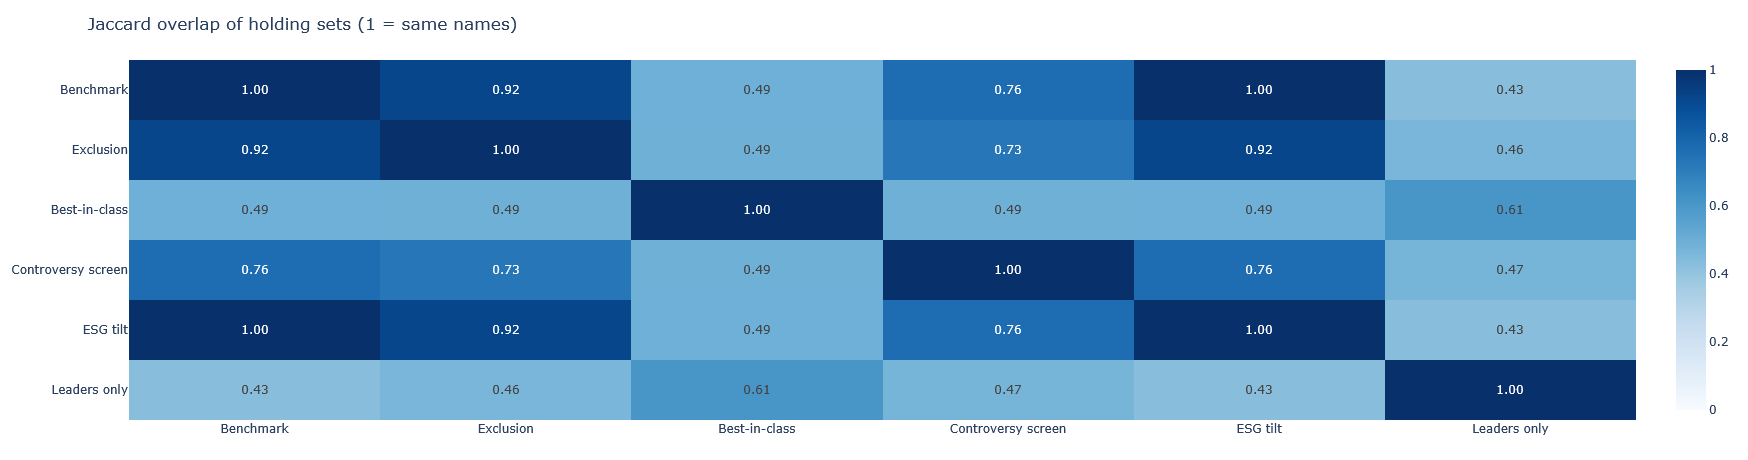

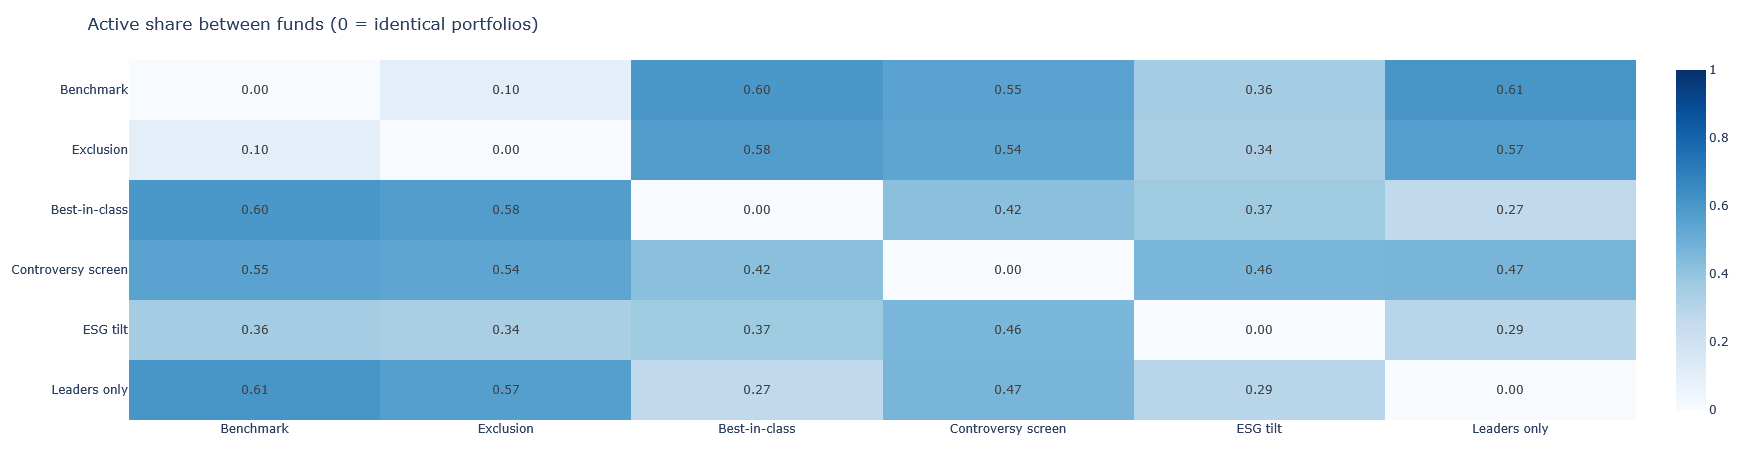

In [4]:
jac = 1 - el.distance_matrix(funds, "jaccard")
act = el.distance_matrix(funds, "active_share")
el.fig_matrix(jac.round(3), "Jaccard overlap of holding sets (1 = same names)", zmax=1).show()
el.fig_matrix(act.round(3), "Active share between funds (0 = identical portfolios)", zmax=1).show()

In [5]:
print(f"Exclusion vs Benchmark:      Jaccard {jac.loc['Exclusion', 'Benchmark']:.2f}   "
      f"active share {act.loc['Exclusion', 'Benchmark']:.2f}")
print(f"Exclusion vs Best-in-class:  Jaccard {jac.loc['Exclusion', 'Best-in-class']:.2f}   "
      f"active share {act.loc['Exclusion', 'Best-in-class']:.2f}")
print(f"ESG tilt vs Benchmark:       Jaccard {jac.loc['ESG tilt', 'Benchmark']:.2f}   "
      f"active share {act.loc['ESG tilt', 'Benchmark']:.2f}")

Exclusion vs Benchmark:      Jaccard 0.92   active share 0.10
Exclusion vs Best-in-class:  Jaccard 0.49   active share 0.58
ESG tilt vs Benchmark:       Jaccard 1.00   active share 0.36


Three readings.

1. **The exclusion fund is almost the benchmark.** It drops thirty-one names, but
   they carry little weight: you would trade about a tenth of the portfolio to
   turn one into the other. The screen most commonly behind an "ethical" label is,
   in weight terms, a small adjustment.
2. **Two sustainable funds can be much further from each other than either is
   from the market.** Exclusion and best-in-class are nearly six times further
   apart than exclusion is from the benchmark.
3. **The ESG tilt holds exactly the same companies as the benchmark** — a Jaccard
   of 1.00 — **and is a different fund**, with an active share of about 0.36.
   Holdings overlap is not portfolio similarity. Any audit that compares lists of
   names will call these two identical.

---
## 4. What does each fund actually deliver?

Now describe each fund by what it holds, weighted.

In [6]:
profile = el.fund_profile(funds, u)
profile.round(2)

,holdings,weighted ESG risk,weighted E risk,"fossil, narrow (%)","fossil, broad (%)",weapons (%),vice (%),high controversy (%)
Benchmark,368.0,22.85,4.88,5.52,8.38,2.84,1.80,55.33
Exclusion,337.0,21.59,3.90,0.00,3.18,0.00,0.00,54.04
Best-in-class,181.0,17.28,3.55,3.98,7.78,0.00,0.65,35.57
Controversy screen,281.0,19.95,4.78,5.61,10.72,0.96,0.99,0.00
ESG tilt,368.0,17.24,2.86,1.23,2.45,0.33,0.55,39.23
Leaders only,158.0,15.71,2.28,0.47,0.70,0.00,0.00,39.41


Read down the columns, not across the rows.

* **Best-in-class keeps oil and gas.** It excludes no sector by design, so it
  holds the lower-risk half of the Energy sector — nine companies, about 4% of the
  fund. Under its own rule that is not a breach; it is the point. A member who
  assumed "sustainable" meant "no fossil fuels" has bought something else.
* **The controversy screen removes more than half the market.** It drops only
  87 companies, but they carry about 55% of the benchmark's weight: most of the
  largest companies in the market carry a significant controversy. Utilities and
  real estate are barely touched, so they gain weight — and with utilities comes
  fossil-fired generation. Under the broad definition in Section 6 this fund ends
  up with **more** fossil exposure than the market: about 10.7% against 8.4%.
* **Leaders-only has the lowest ESG risk of all, and is a technology fund.** More
  than 40% of it sits in one sector, against about 18% for the benchmark. Part of
  what looks like an ESG result is a sector bet.

Each fund is excellent on the dimension its rule targets and unremarkable, or
worse, on the others. That is the same composition result Lab 9a found in the
super panel, now produced deliberately.

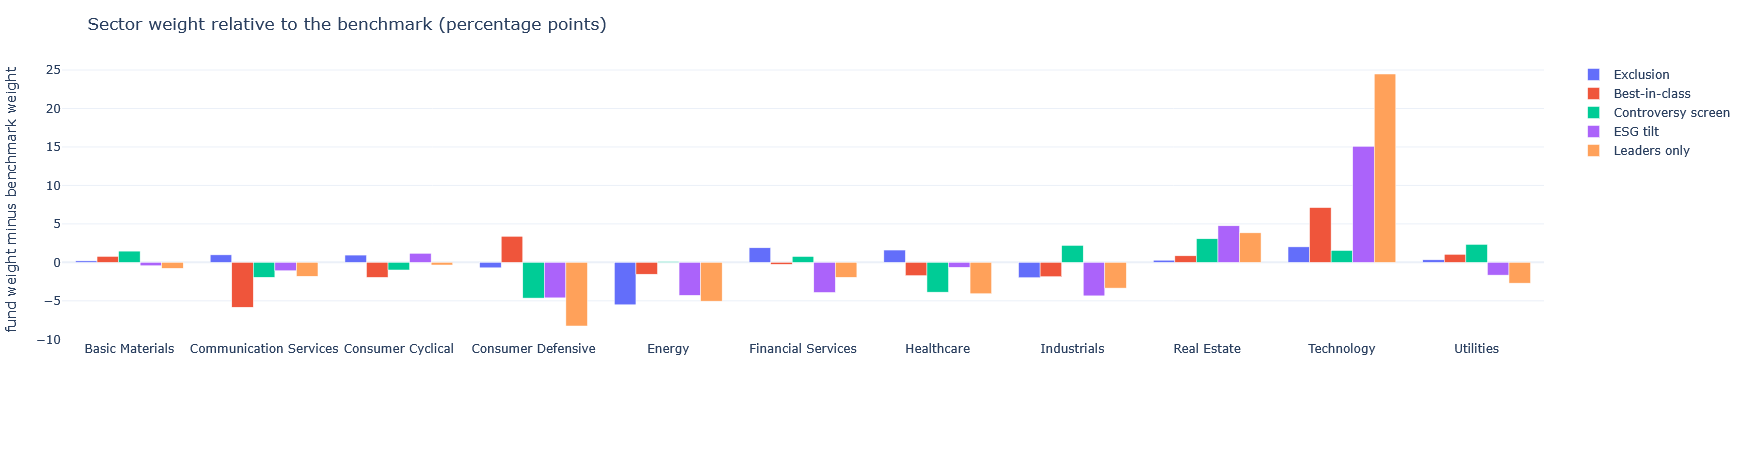

In [7]:
sectors = pd.DataFrame({f: 100 * funds[f].groupby(u["Sector"]).sum() for f in funds})
tilt = sectors.drop(columns="Benchmark").sub(sectors["Benchmark"], axis=0)
fig = go.Figure()
for f in tilt.columns:
    fig.add_trace(go.Bar(name=f, x=tilt.index, y=tilt[f]))
fig.update_layout(barmode="group", height=460,
                  title="Sector weight relative to the benchmark (percentage points)",
                  yaxis_title="fund weight minus benchmark weight",
                  margin=dict(l=10, r=20, t=60, b=120))
fig.show()

---
## 5. Which funds are twins?

Cluster the six funds on the active share between them. Because active share is
an $L_1$ distance rather than a Euclidean one, the tree uses **average** linkage:
Ward's method assumes squared Euclidean distances and would be the wrong tool.

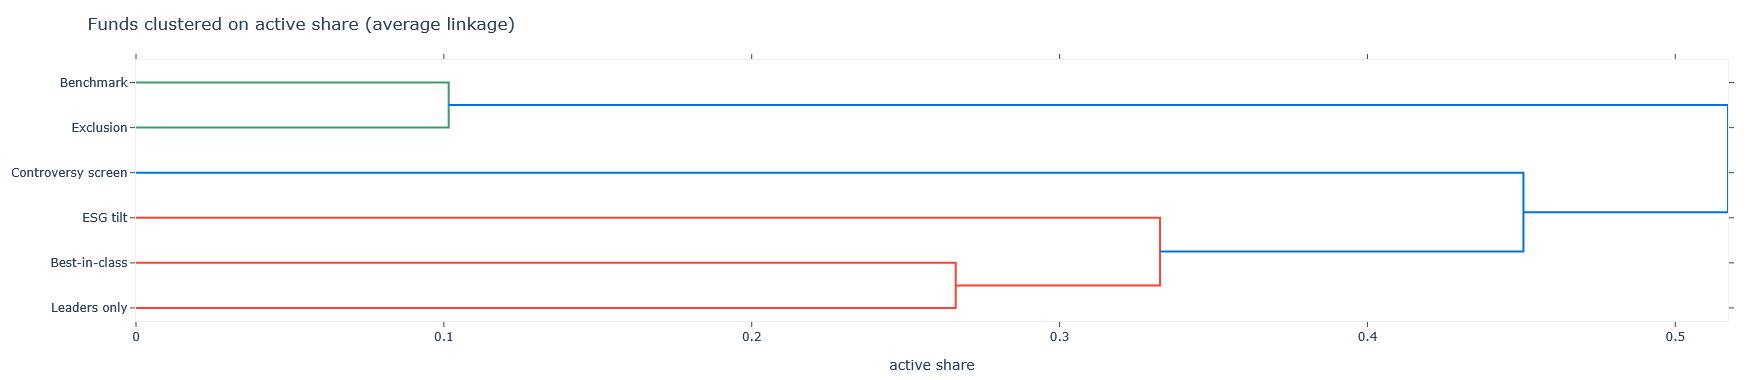

In [8]:
W = funds.T.values                      # one row per fund, one column per company
fig = ff.create_dendrogram(W, labels=list(funds.columns), orientation="left",
                           distfun=lambda X: pdist(X, "cityblock") / 2,
                           linkagefun=lambda d: linkage(d, "average"))
fig.update_layout(title="Funds clustered on active share (average linkage)",
                  height=380, xaxis_title="active share", margin=dict(l=10, r=20, t=60, b=40))
fig.show()

The benchmark and the exclusion fund merge first and closest: the exclusion
screen barely moves the portfolio. Best-in-class and leaders-only pair up on the
other side — both keep "low-risk" names, one within each sector and one across
the whole market. The tilt joins that pair, but only narrowly: it is almost as
close to the benchmark. The controversy screen joins last.

So the funds organise themselves into **"the market, lightly edited"** and
**"a different portfolio"**, and the word *sustainable* could sit on either. A
label that does not say which family it belongs to is not telling you very much.

> **Core exercise 5.1** — Add a sixth fund that excludes fossil fuels under the
> **broad** definition used in Section 6 (`el.fossil_mask(u, "broad")`), weighted
> by market capitalisation. Where does it land in the tree?

---
## 6. Claim versus holdings: "excludes fossil fuels"

Suppose the exclusion fund is marketed as **excluding fossil fuels**. Is the
claim true?

That depends entirely on what "fossil fuels" means, which is the normalisation
problem from the lecture made concrete.

* **Narrow:** the Energy sector — producers, refiners, pipelines, services.
  This is what the exclusion rule actually removed.
* **Broad:** the Energy sector *plus* utilities that generate or distribute
  fossil energy. This is how the source behind Lab 9a defines the category,
  explicitly including power companies generating electricity from fossil fuels.

Run the claim through both.

In [9]:
w = funds["Exclusion"]
for definition in ["narrow", "broad"]:
    held = w[(w > 0) & el.fossil_mask(u, definition)]
    print(f"{definition:6s} definition: {len(held):2d} holdings contradict the claim, "
          f"{100 * held.sum():.2f}% of the fund")

shortlist = el.claim_check(w, u, definition="broad")
shortlist.head(10).round(3)

narrow definition:  0 holdings contradict the claim, 0.00% of the fund
broad  definition: 26 holdings contradict the claim, 3.18% of the fund


,Company,Sector,Industry,weight_pct,clean_under_narrow_definition
Symbol,,,,,
NEE,"Nextra Energy, Inc.",Utilities,Utilities - Regulated Electric,0.374,True
DUK,Duke Energy Corporation,Utilities,Utilities - Regulated Electric,0.280,True
D,"Dominion Energy, Inc",Utilities,Utilities - Regulated Electric,0.255,True
SO,The Southern Company,Utilities,Utilities - Regulated Electric,0.233,True
EXC,Exelon Corporation,Utilities,Utilities - Regulated Electric,0.186,True
AEP,"American Electric Power Company, Inc.",Utilities,Utilities - Regulated Electric,0.170,True
SRE,Sempra,Utilities,Utilities - Diversified,0.140,True
PEG,Public Service Enterprise Group Incorporated,Utilities,Utilities - Regulated Electric,0.130,True
ED,"Consolidated Edison, Inc.",Utilities,Utilities - Regulated Electric,0.125,True


Under the narrow definition the claim is true: zero holdings contradict it.
Under the broad definition, twenty-six utilities — about 3.2% of the fund —
contradict it. Same fund, same holdings, opposite verdict.

This is the pattern in all three Australian greenwashing judgments: a screen
**described accurately in principle** and **not supported by the data in
practice**. Nobody here did anything dishonest; the claim and the screen simply
used different definitions of the same two words.

Two further lessons sit in this table.

* **The shortlist is ranked, and it carries an innocent explanation.**
  `clean_under_narrow_definition` tests the one excuse this data can test: that
  the manager applied the narrow definition. Every row passes it. Before anyone
  alleges anything, that explanation has to be ruled out.
* **An industry label is a proxy, and the proxy can be wrong.** The top row is a
  regulated electricity utility that is also among the largest renewable
  generators in the United States. An industry code cannot see a generation mix.
  The broad definition flags it, and whether that is fair is a question the
  holdings data cannot answer.

Look at the company name in that top row, too. The source file spells it
**"Nextra"**. A reconciliation that joined on names rather than tickers would
have missed it entirely: the entity-resolution problem from Lab 7c, turning up
exactly where it does the most damage.

> **Core exercise 6.1** — Run `el.claim_check` for the best-in-class and
> controversy funds. Which of the three screened funds could truthfully claim to
> exclude fossil fuels under each definition?

---
## 7. Reading the rule back from the portfolio

A supervisor usually has the holdings and the marketing, but not the rule. Can
the rule be recovered from the holdings alone?

Treat each fund as a classification problem: for every company in the universe,
*is it held?* Fit a shallow decision tree on features a supervisor could observe,
and read the tree. If the tree is simple and accurate, it has found the rule.

In [10]:
X = el.screen_features(u)
for name in ["Exclusion", "Controversy screen", "Leaders only", "Best-in-class"]:
    held = (funds[name] > 0).astype(int)
    tree = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X, held)
    print(f"=== {name}:  accuracy {tree.score(X, held):.3f}   "
          f"(guessing the majority class: {max(held.mean(), 1 - held.mean()):.3f})")
    print(export_text(tree, feature_names=list(X.columns), decimals=2))

=== Exclusion:  accuracy 1.000   (guessing the majority class: 0.916)
|--- energy_sector <= 0.50
|   |--- weapons_industry <= 0.50
|   |   |--- vice_industry <= 0.50
|   |   |   |--- class: 1
|   |   |--- vice_industry >  0.50
|   |   |   |--- class: 0
|   |--- weapons_industry >  0.50
|   |   |--- class: 0
|--- energy_sector >  0.50
|   |--- class: 0

=== Controversy screen:  accuracy 1.000   (guessing the majority class: 0.764)
|--- controversy <= 2.50
|   |--- class: 1
|--- controversy >  2.50
|   |--- class: 0

=== Leaders only:  accuracy 1.000   (guessing the majority class: 0.571)
|--- esg_risk <= 20.05
|   |--- g_risk <= 10.05
|   |   |--- class: 1
|   |--- g_risk >  10.05
|   |   |--- e_risk <= 1.05
|   |   |   |--- class: 1
|   |   |--- e_risk >  1.05
|   |   |   |--- class: 0
|--- esg_risk >  20.05
|   |--- class: 0

=== Best-in-class:  accuracy 1.000   (guessing the majority class: 0.508)
|--- sector_risk_rank <= 0.50
|   |--- class: 1
|--- sector_risk_rank >  0.50
|   |--- 

The trees recover every rule, and read like the rules themselves: the exclusion
fund is three industry flags, the controversy screen is a single cut on
controversy level, the best-in-class fund is a single cut on **within-sector**
risk rank.

(The leaders-only tree has one stray branch. It is chasing a rounding artefact:
three companies show an ESG risk of exactly 20.0, two are banded Low and one is
banded Medium, presumably because their unrounded scores straddle 20.)

Now take away the one feature that makes best-in-class easy.

In [11]:
held = (funds["Best-in-class"] > 0).astype(int)
Xr = X.drop(columns="sector_risk_rank")
tree = DecisionTreeClassifier(max_depth=3, random_state=0).fit(Xr, held)
print(f"Best-in-class without the within-sector rank: accuracy {tree.score(Xr, held):.3f}\n")
print(export_text(tree, feature_names=list(Xr.columns), decimals=2))

Best-in-class without the within-sector rank: accuracy 0.842

|--- esg_risk <= 22.30
|   |--- e_risk <= 3.35
|   |   |--- esg_risk <= 21.05
|   |   |   |--- class: 1
|   |   |--- esg_risk >  21.05
|   |   |   |--- class: 0
|   |--- e_risk >  3.35
|   |   |--- esg_risk <= 21.50
|   |   |   |--- class: 1
|   |   |--- esg_risk >  21.50
|   |   |   |--- class: 1
|--- esg_risk >  22.30
|   |--- s_risk <= 9.40
|   |   |--- esg_risk <= 26.65
|   |   |   |--- class: 1
|   |   |--- esg_risk >  26.65
|   |   |   |--- class: 0
|   |--- s_risk >  9.40
|   |   |--- g_risk <= 3.80
|   |   |   |--- class: 1
|   |   |--- g_risk >  3.80
|   |   |   |--- class: 0



Without the within-sector rank, the tree reaches about 84% and produces a
tangle of risk thresholds that looks nothing like the real rule. The rule has
not become more complicated. The supervisor has lost the feature that expresses
it.

**You can only audit a rule you have the features for.** A best-in-class screen
is defined *relative to peers*, so auditing it needs the peer group — which is
exactly the peer-group construction problem from Lab 7c, returning as a
supervisory requirement.

> **Core exercise 7.1** — Fit the same tree on the ESG tilt fund. What do you
> get, and why? What does that tell you about auditing an integration strategy
> from a holdings *list* rather than from its *weights*?

---
## 8. Exercises

### Core

1. **How strict is best-in-class?** Rebuild it with `keep_share=0.3` and
   `keep_share=0.7` (`el.build_fund(u, "Best-in-class", keep_share=...)`). How do
   the number of holdings, the weighted ESG risk and the Energy weight move?

2. **The price of a tilt.** Sweep the tilt strength from 0 to 3
   (`el.build_fund(u, "ESG tilt", strength=...)`). Plot weighted ESG risk against
   active share relative to the benchmark. That curve is a preview of the trade-off
   Week 10 optimises directly.

3. **A label test.** Suppose a label required *zero* vice exposure and broad
   fossil exposure below 1%. Which of your funds would qualify? Is the fund with
   the lowest ESG risk among them?

### Stretch

4. **Stacked screens.** Many real "ethical" products apply an exclusion *and* a
   best-in-class rule. Build that fund. Is it closer, in active share, to the
   exclusion fund or to the best-in-class fund, and why?

5. **A sparser supervisor.** Remove `energy_sector` from the features and refit
   the exclusion tree. What does the tree use instead, and would you trust its
   rule on a different universe?

6. **Back to Lab 9a.** Using the proxies available here (broad fossil fuels,
   weapons, vice), build a three-category exposure vector for each of your six
   funds and cluster them the way Lab 9a clustered super options. Do the clusters
   match the two families you found in Section 5?

---

### What to take away

* Reasonable screens applied to one universe produce portfolios that barely
  resemble each other. **The label does not identify the rule.**
* **Holdings overlap is not portfolio similarity.** A tilt can hold every name in
  the benchmark and still be a different fund.
* Every screen is excellent on its own target and unremarkable, or worse, on
  others: a controversy screen can raise fossil exposure above the market's.
* Whether a claim is true can depend entirely on a definition. **Normalise to the
  most specific definition the source supports**, and rank your shortlist by the
  innocent explanations you have already tested.
* A rule can be read back from a portfolio **only if you have the features that
  express it.**

### Where this goes next

**Week 10** stops treating screens as filters and starts treating them as
constraints inside an optimiser: exposure caps, ESG-score targets, cluster
limits. The question changes from "what does this rule hold?" to **"what does
this rule cost?"**